# Setup and Checking for Access

Installing necessary libraries

In [1]:
!pip install matplotlib
!pip install scipy

In [2]:
!sudo yum install -y java-11-amazon-corretto-headless

Last metadata expiration check: 0:19:10 ago on Sat Jul 18 01:42:24 2026.
Package java-11-amazon-corretto-headless-1:11.0.31+11-1.amzn2023.x86_64 is already installed.
Dependencies resolved.
Nothing to do.
Complete!


In [3]:
import os
import glob

# Search for the installed Java directory
java_paths = glob.glob('/usr/lib/jvm/java-11*')

if java_paths:
    # Dynamically set the environment variable to the found path
    os.environ["JAVA_HOME"] = java_paths[0]
    print(f"JAVA_HOME successfully set to: {os.environ['JAVA_HOME']}")
else:
    print("Java not found. Did the yum install command work?")

JAVA_HOME successfully set to: /usr/lib/jvm/java-11-amazon-corretto.x86_64


Import necessary libraries

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import time
import numpy as np
from scipy.stats import chi2_contingency

Start a Spark Session

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, isnan, when, input_file_name, countDistinct, desc, round, avg, sum
from pyspark.sql.functions import date_format, from_utc_timestamp
import pyspark.sql.functions as F

spark = (
    SparkSession.builder
    .appName("DAT204M-EDA-Sagemaker")
    .master("local[*]")
    .config("spark.jars.packages",
            "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262")
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .config("spark.hadoop.fs.s3a.aws.credentials.provider",
            "com.amazonaws.auth.InstanceProfileCredentialsProvider")
    .config("spark.driver.memory", "10g")
    .getOrCreate()
)

INPUT_PATH = "s3a://dat204m-project-g3/cleaned_data_final/"
OUTPUT_PATH = "s3a://dat204m-project-g3/sampled_eda_data/"


print("Spark ready:", spark.version)

:: loading settings :: url = jar:file:/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.0.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/ec2-user/.ivy2/cache
The jars for the packages stored in: /home/ec2-user/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
com.amazonaws#aws-java-sdk-bundle added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-3758038a-22d3-4748-ab84-af7b44ca0d26;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
:: resolution report :: resolve 299ms :: artifacts dl 8ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.262 from central in [default]
	org.apache.hadoop#hadoop-aws;3.3.4 from central in [default]
	org.wildfly.openssl#wildfly-openssl;1.0.7.Final from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|

26/07/18 02:01:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Spark ready: 3.3.0


## Sampling
Considering that our cleaned data is still composed of an estimate of 70GB, we will opt to perform stratified sampling by getting 1% of the data from every month, therefore reducing the amount of data we will be handling for EDA from 70GB to around 700MB. 

In [6]:
# # ==============================================================================
# # DO NOT RUN THIS CELL 
# # This script performs the 70GB stratified sampling and writes to S3. 
# # It was already executed by Imman. 
# # ==============================================================================
# df = spark.read.parquet(INPUT_PATH)

# # Create the stratification key (yyyy-MM)
# df_time = df.withColumn("year_month", date_format("stime", "yyyy-MM"))

# # Dynamically identify all unique months
# # NOTE: This triggers a full read of the 'stime' column across all 180 shards. 
# # It will take a few minutes to compute, but it is necessary for stratification.
# print("Scanning dataset to find all unique months (this will take a moment)...")
# distinct_months_rows = df_time.select("year_month").distinct().collect()

# # Clean the list and remove any potential Null timestamps
# distinct_months = [row["year_month"] for row in distinct_months_rows if row["year_month"] is not None]
# print(f"Found {len(distinct_months)} unique months: {distinct_months}")

# # Set up the sampling fractions (e.g., 0.01 for exactly 1% of every month)
# SAMPLE_FRACTION = 0.01
# fractions = {month: SAMPLE_FRACTION for month in distinct_months}

# # Execute the stratified sample
# print(f"Executing stratified sampling at {SAMPLE_FRACTION*100}% per month...")
# df_sampled = df_time.stat.sampleBy("year_month", fractions, seed=42)

# # Save the sampled dataset back to S3
# print(f"Writing sampled data to: {OUTPUT_PATH}")
# # Using coalesce(4) matches your 4 vCPUs. It prevents Spark from writing 180 tiny files, 
# # instead outputting 4 clean, medium-sized Parquet files for your team to easily read.
# df_sampled.coalesce(4).write.mode("overwrite").parquet(OUTPUT_PATH)

# print("Stratified sampling complete and saved to S3!")

# Exploratory Data Analysis

As we have saved our sampled data to sample_eda_data in S3, we are going to load it

In [7]:
EDA_DATA_PATH = "s3a://dat204m-project-g3/sampled_eda_data/"
df = spark.read.parquet(EDA_DATA_PATH)

26/07/18 02:01:46 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties


**About the Dataset**

* **Format:** Parquet (columnar, compressed)
* **Storage:** 4 Parquet files
* **File Size:** Approximately **340–370 MB** per file
* **Content:** 1% of data from each month (May to October 2023)
* **Dataset:** Mercari Dataset from HuggingFace (https://huggingface.co/datasets/mercari-us/merrec)

In [8]:
# Enable clean HTML formatting for Spark DataFrames
spark.conf.set("spark.sql.repl.eagerEval.enabled", True)

In [9]:
# ==========================================
# PHASE 1: DIRECTORY VALIDATION (The Proof)
# ==========================================
start = time.time()
row_count = df.count()
elapsed = time.time() - start

print("\n--- Validating Directory Contents ---")

# Count total aggregate rows
total_rows = df.count()
total_columns = len(df.columns)

print(f"Total Rows in Dataset: {total_rows:,}")
print(f'Total Columns in Dataset: {total_columns}')
print(f'Counted in {elapsed:.1f} seconds')


--- Validating Directory Contents ---
Total Rows in Dataset: 11,430,493
Total Columns in Dataset: 14
Counted in 2.3 seconds


There are 11,430,493 rows in total and 14 columns across 4 Parquet files 

In [10]:
# Extract the unique file names to prove all shards were read
file_distribution = df.withColumn("source_file", input_file_name()) \
    .groupBy("source_file").agg(count("*").alias("row_count"))

total_files_read = file_distribution.count()
print(f"Total Parquet Shards Read: {total_files_read}")

# Display the first 5 shards to verify they match your Athena outputs
print("\nSample of individual files processed:")
file_distribution.show(5, truncate=False)

Total Parquet Shards Read: 4

Sample of individual files processed:


+-------------------------------------------------------------------------------------------------------------+---------+
|source_file                                                                                                  |row_count|
+-------------------------------------------------------------------------------------------------------------+---------+
|s3a://dat204m-project-g3/sampled_eda_data/part-00000-e4d68cc2-2015-4805-a093-f03af57fd135-c000.snappy.parquet|2864817  |
|s3a://dat204m-project-g3/sampled_eda_data/part-00001-e4d68cc2-2015-4805-a093-f03af57fd135-c000.snappy.parquet|2931512  |
|s3a://dat204m-project-g3/sampled_eda_data/part-00002-e4d68cc2-2015-4805-a093-f03af57fd135-c000.snappy.parquet|2879205  |
|s3a://dat204m-project-g3/sampled_eda_data/part-00003-e4d68cc2-2015-4805-a093-f03af57fd135-c000.snappy.parquet|2754959  |
+-------------------------------------------------------------------------------------------------------------+---------+



In [11]:
# ==========================================
# PHASE 2: COMPREHENSIVE EDA
# ==========================================
print("\n--- Basic Schema ---")
df.printSchema()

print("\n--- Checking for Missing Values ---")
# This calculates the exact number of nulls across the features we kept
missing_val_exprs = [
    count(when(isnan(c) | col(c).isNull(), c)).alias(c)
    for c in df.columns 
    if df.schema[c].dataType.typeName() not in ['timestamp', 'date']
]
df.select(*missing_val_exprs)


--- Basic Schema ---
root
 |-- user_id: long (nullable = true)
 |-- stime: timestamp (nullable = true)
 |-- session_id: string (nullable = true)
 |-- item_id: long (nullable = true)
 |-- event_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- price: double (nullable = true)
 |-- c0_name: string (nullable = true)
 |-- c1_name: string (nullable = true)
 |-- c2_name: string (nullable = true)
 |-- brand_name: string (nullable = true)
 |-- item_condition_name: string (nullable = true)
 |-- year_month: string (nullable = true)


--- Checking for Missing Values ---


user_id,session_id,item_id,event_id,product_id,name,price,c0_name,c1_name,c2_name,brand_name,item_condition_name,year_month
0,0,0,0,0,0,0,0,0,0,0,0,0


From the data above, there are 2 long data, 1 timestamp data, 1 double data, and 10 string values

There are no missing values for all 14 columns

The description of each column in the dataset is shown below:

| Column                | Description                                                                                                                                     |
| --------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------- |
| `user_id`             | Globally unique user account ID.                                                                                                                |
| `session_id`          | User-level unique session ID.                                                                                                                   |
| `stime`               | Timestamp in UTC timezone.                                                                                                                      |
| `year_month`          | Derived from `stime` in `YYYY-MM` format, representing the year and month of each event.|
| `event_id`            | Action event ID.                                                                                                                                |
| `item_id`             | Globally unique item ID, representing a single listing post.                                                                                    |
| `product_id`          | Concatenation of `brand_id` and `c2_id`.                                                                                                        |
| `name`                | Title text of the item.                                                                                                                         |
| `price`               | Price of the item in USD.                                                                                                                       |
| `c0_name`             | Text label of the item's level-0 category.                                                                                                      |
| `c1_name`             | Text label of the item's level-1 category.                                                                                                      |
| `c2_name`             | Text label of the item's level-2 category.                                                                                                      |
| `brand_name`          | Text label of the item's brand.                                                                                                                 |
| `item_condition_name` | Text label of the item's condition (e.g., New, Good, Fair).                                                                                     |


In [12]:
print("\n--- Checking for Duplicates ---")

# 1. Group by the specific identifiers and count occurrences
duplicate_groups = df.groupBy("user_id", "stime", "session_id", "item_id").agg(count("*").alias("occurrence_count"))

# 2. Filter to find only the combinations that appear more than once
duplicates = duplicate_groups.filter(col("occurrence_count") > 1)

# 3. Action: Count the total number of duplicate combinations
total_duplicates = duplicates.count()

print(f"Total duplicate combinations found: {total_duplicates:,}")

# 4. Display a sample if duplicates exist
if total_duplicates > 0:
    print("\nSample of duplicated records (sorted by most occurrences):")
    duplicates.orderBy(col("occurrence_count").desc()).show(5, truncate=False)
else:
    print("\nPerfect! No duplicate records found for the given key combination.")


--- Checking for Duplicates ---


Total duplicate combinations found: 1,060

Sample of duplicated records (sorted by most occurrences):


[Stage 30:=======================================>                (12 + 4) / 17]

+--------+-------------------+----------------------------------------------------------------+---------+----------------+
|user_id |stime              |session_id                                                      |item_id  |occurrence_count|
+--------+-------------------+----------------------------------------------------------------+---------+----------------+
|13932513|2023-05-17 19:25:11|aba3f57e2a01b9612189a46a15f9ec5128759144590b8a43ff48046f7f825111|105981293|2               |
|3813077 |2023-05-02 23:21:38|74aaa59cf09cbbb9951d8839fd6288124be79b969fffa67e0cff347c3a67239a|225905434|2               |
|26105605|2023-05-26 12:10:12|63f737743c5962eff1ada57d660e9064e994ed8df38cfcf0c4401b6976e1da88|105569422|2               |
|55880854|2023-05-20 00:35:25|459a67517703a33f731e709cf13923cb6b4ec607479c101ea1410fa778b95e3d|38662253 |2               |
|29207527|2023-05-15 13:58:15|22a69126eb5eae10ff630c004c9a2d118c75de27ebc9635bdf229f33c54491a8|40914902 |2               |
+--------+------

For duplicates, we group it by "user_id", "stime", "session_id", "item_id", as shown above there are 1060 occurences

In [13]:
# Display the first 5 rows
print("\n--- Head of Dataset ---")
df.limit(6)


--- Head of Dataset ---


user_id,stime,session_id,item_id,event_id,product_id,name,price,c0_name,c1_name,c2_name,brand_name,item_condition_name,year_month
54896847,2023-05-20 03:09:46,9cd412bdcea92541e...,231043011,item_view,22105_1101,Puff sleeve tie top,9.0,Women,Tops & blouses,Blouse,SHEIN,Like new,2023-05
54899488,2023-05-04 00:46:25,df7af1950ae474fa6...,87814591,item_view,22635_2990,1986 topps baseba...,80.0,Toys & Collectibles,Sports Trading Cards,Baseball Trading ...,Topps,Like new,2023-05
54902928,2023-05-11 05:15:14,ba782d47de1ba8801...,31205696,item_view,14248_1176,Vintage Miller Be...,35.0,Men,Tops,T-shirts,Miller,Like new,2023-05
56163126,2023-05-15 00:17:19,f665ccf7f3caff832...,224122501,item_view,2693_1339,Bath and Body Wor...,79.0,Beauty,Skin care,Body,Bath & Body Works,New,2023-05
34163376,2023-05-01 17:35:38,ee8638a1b9f0b1f1a...,232158130,item_like,0_464,Coach mini phone ...,80.0,Women,Women's handbags,Crossbody Bags,None,New,2023-05
34164325,2023-05-06 04:44:19,a739ee72e649e0742...,58444656,item_view,12630_2194,LIKE NEW! RARE ♥️...,39.0,Women,Tops & blouses,Tank Tops,lululemon athletica,Like new,2023-05


Convert stime to Asia/Tokyo timezone as currrently it is in UTC timezone

In [14]:
df = df.withColumn(
    "stime_jst",
    from_utc_timestamp("stime", "Asia/Tokyo")
)

## Price Distribution

**Price Distribution Insights**
* There are over 11.4 million observations of 'price' values
* Most observations fall between 13.54 and 55.00, with a median of 25.00.
* The distribution is highly right-skewed, as reflected by the mean being substantially larger than the median.
* Extreme values (up to 5000) indicate the presence of significant outliers.

In [15]:
df.agg(
    F.count("price").alias("Count"),
    F.min("price").alias("Minimum"),
    F.expr("percentile_approx(price, 0.25)").alias("Q1"),
    F.expr("percentile_approx(price, 0.5)").alias("Median"),
    F.expr("percentile_approx(price, 0.75)").alias("Q3"),
    F.max("price").alias("Maximum"),
    F.avg("price").alias("Mean"),
    F.stddev("price").alias("Standard Deviation")
).show(truncate=False)

[Stage 39:>                                                         (0 + 1) / 1]

+--------+-------+-----+------+----+-------+-----------------+------------------+
|Count   |Minimum|Q1   |Median|Q3  |Maximum|Mean             |Standard Deviation|
+--------+-------+-----+------+----+-------+-----------------+------------------+
|11430493|1.0    |13.54|25.0  |55.0|5000.0 |61.51486253654418|140.67764854937153|
+--------+-------+-----+------+----+-------+-----------------+------------------+



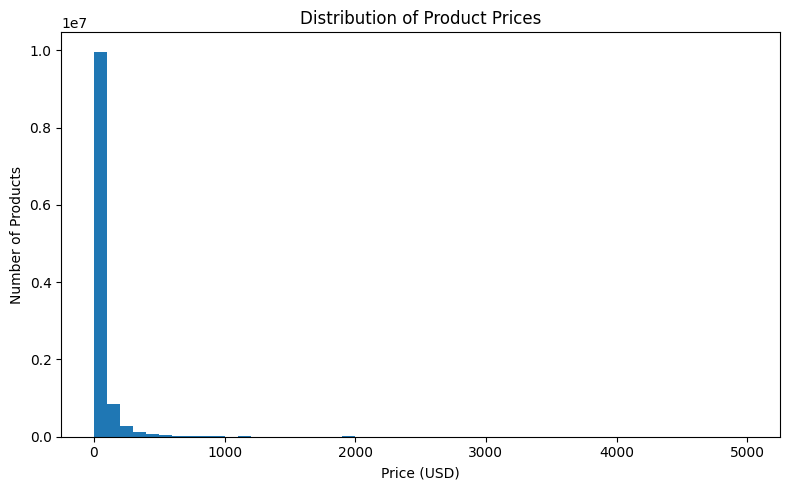

In [16]:
price_df = df.select("price").toPandas()

plt.figure(figsize=(8,5))
plt.hist(price_df["price"], bins=50)
plt.title("Distribution of Product Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

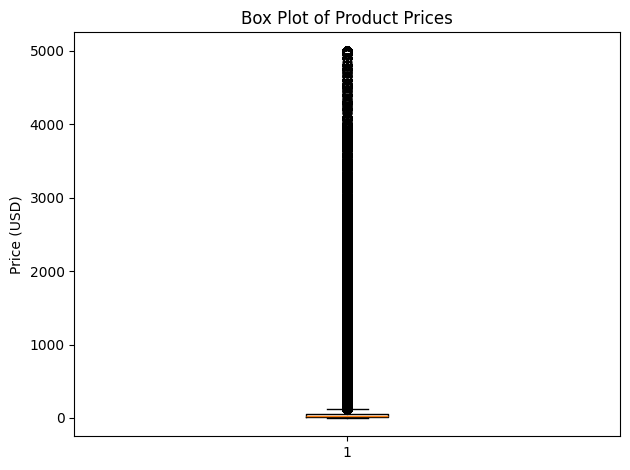

In [17]:
plt.boxplot(price_df["price"])

plt.title("Box Plot of Product Prices")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

**Average Price Insight of Category 0**
* Product prices vary substantially across categories, with the highest average price (Electronics: 102.94) being more than three times the lowest (Kids: 30.13).
* Categories associated with technology, equipment, and durable goods tend to command higher average prices.
* Categories focused on children's products, office supplies, beauty products, and pet supplies generally have lower average prices.

In [18]:
avg_price_category0 = (
    df.groupBy("c0_name")
      .agg(F.avg("price").alias("avg_price"))
      .orderBy(F.desc("avg_price"))
)

avg_price_category0.show()

[Stage 41:======================================>                  (8 + 4) / 12]

+--------------------+------------------+
|             c0_name|         avg_price|
+--------------------+------------------+
|         Electronics| 102.9443038964767|
|               Tools| 88.81450926631125|
|               Other| 87.06883790671681|
|   Sports & outdoors| 84.76329964590022|
|                 Men| 75.77431727841737|
|               Books| 70.21197270320184|
|Vintage & collect...| 66.17431124368395|
|               Women| 64.36050920826438|
|    Garden & Outdoor|57.626448149840115|
| Toys & Collectibles| 55.80091990522814|
|            Handmade|55.030767937627175|
|                Home| 46.87858046387187|
|       Arts & Crafts|41.499456278781686|
|              Beauty|41.181788806674575|
|              Office|  34.7880008671048|
|        Pet Supplies|34.434757733934966|
|                Kids|30.127136807096715|
+--------------------+------------------+



**Average Price Insight of Category 1**
* High-value subcategories are primarily concentrated in electronics, furniture, industrial equipment, and luxury accessories.
* The highest-priced subcategory (Sauna & Hot Tub Equipment: 280.03) has an average price approximately twice that of Patio Furniture (137.07), indicating substantial pricing variability even among premium product groups.
* Furniture-related subcategories occupy several positions in the top 20
* Technology-focused subcategories consistently command premium prices 

In [19]:
avg_price_category1 = (
    df.groupBy("c1_name")
      .agg(F.avg("price").alias("avg_price"))
      .orderBy(F.desc("avg_price"))
)

avg_price_category1.show()

[Stage 44:======================================>                  (8 + 4) / 12]

+--------------------+------------------+
|             c1_name|         avg_price|
+--------------------+------------------+
|Sauna & Hot Tub E...|280.02619718309853|
|              Drones|251.86714412285883|
|Living Room Furni...| 228.2554185152322|
|   Kitchen Furniture|222.23944444444444|
|     Bags and purses|196.88247569298812|
|Cameras & photogr...|193.26247094879324|
|   Bedroom Furniture|193.02094354838707|
| Musical instruments|191.01042195320682|
|     Virtual Reality|181.08447302608073|
| Computers & Laptops|181.00954221912073|
|   Welding Equipment| 179.2587082405345|
|Computer Componen...|178.21515015646165|
|           Strollers|177.71944659407902|
|   Cycling Equipment| 173.1550633855332|
|Outdoor Power Equ...|160.37250085763293|
|           Furniture|160.27326938775514|
|    Women's handbags|151.97299141837473|
| Tablets & E-readers| 140.4877271725961|
|Home Office Furni...|138.42385498174232|
|     Patio Furniture|137.07002930402928|
+--------------------+------------

**Average Price Insight of Category 2**
* Product prices vary dramatically across sub-subcategories, with Pergolas (1,490.00) having an average price nearly four times higher than Electric Skateboards (365.80) among the top-priced items.
* The highest average prices are concentrated in large outdoor structures, industrial equipment, high-performance sporting goods, premium furniture, and consumer electronics.
* Some categories with unexpectedly high averages (e.g., Trading Card Games, Correction Fluid, and Marker Refills) may reflect limited sample sizes, luxury variants, or outlier products

In [20]:
avg_price_category2 = (
    df.groupBy("c2_name")
      .agg(F.avg("price").alias("avg_price"))
      .orderBy(F.desc("avg_price"))
)

avg_price_category2.show()

[Stage 47:==========================================>              (9 + 3) / 12]

+--------------------+------------------+
|             c2_name|         avg_price|
+--------------------+------------------+
|            Pergolas|            1490.0|
|  Trading Card Games| 679.6666666666666|
|    Correction Fluid|             647.0|
|  Gravel Bike Frames| 613.0333333333333|
|Complete Triathlo...| 532.4117647058823|
|      Marker Refills| 497.2857142857143|
|             Handbag| 468.9415399188091|
|Fusion Splicers &...|           454.875|
|    Welding Machines|454.08315789473676|
|    Living Room Sets|439.65020000000004|
|       Crimping Dies| 433.3333333333333|
|       Hand Crimpers|429.84823529411767|
|Automotive Wheels...| 418.2359064327485|
|            Hot Tubs|            406.75|
|  Laptops & netbooks| 393.6871549893842|
|Patio Furniture Sets| 391.1643367346939|
|      Soldering Guns|           385.892|
|      Tires & wheels| 382.5851704545454|
|DJ, electronic mu...|378.42857142857144|
|Electric Skateboards|365.79953642384106|
+--------------------+------------

**Average Insight per Brand**
* The highest-priced brands are concentrated in luxury goods, professional equipment, musical instruments, automotive components, and designer fashion.
* Devon Leigh (2,000.00) has an average price nearly double that of Paloma Blanca (1,052.25) among the top 20 brands, demonstrating substantial price variation even within premium brands.

In [21]:
avg_price_brand_name = (
    df.groupBy("brand_name")
      .agg(F.avg("price").alias("avg_price"))
      .orderBy(F.desc("avg_price"))
)

avg_price_brand_name.show()

[Stage 50:==============================================>         (10 + 2) / 12]

+-------------------+------------------+
|         brand_name|         avg_price|
+-------------------+------------------+
|        Devon Leigh|            2000.0|
|       Rickenbacker|            1900.0|
|              Bemer|            1650.0|
|    Kelly Faetanini|            1628.0|
|      KW Suspension|            1600.0|
|            Lakland|            1550.0|
|         Coolstream|            1425.0|
|       Rue De Seine|1255.5555555555557|
|              Rolex|1210.9507475317348|
|    Brooklyn Motors|            1150.0|
|        Jacob & Co.|           1148.32|
|          Neil Lane| 1146.568054054054|
|Sequential Circuits| 1129.142857142857|
|             Hartke|            1100.0|
|             Gorski|            1100.0|
|             Imacon|            1100.0|
|      Martina Liana|1092.7890909090909|
|Vacheron Constantin| 1062.142857142857|
|           Permobil|            1059.8|
|      Paloma Blanca|           1052.25|
+-------------------+------------------+
only showing top

**Average Price Insight per Item Condition**
* Product condition exhibits a general downward trend in average price as condition worsens, although the differences are relatively modest.

In [22]:
avg_price_item_condition = (
    df.groupBy("item_condition_name")
      .agg(F.avg("price").alias("avg_price"))
      .orderBy(F.desc("avg_price"))
)

avg_price_item_condition.show()

[Stage 53:======================================>                  (8 + 4) / 12]

+-------------------+------------------+
|item_condition_name|         avg_price|
+-------------------+------------------+
|               None| 71.11878855444074|
|           Like new|  66.2061316194585|
|                New| 60.26526823580089|
|               Good|59.953399417708944|
|               Poor| 58.91897091318143|
|               Fair| 55.73581727737282|
+-------------------+------------------+



**Average Price Over Time**
* The overall trend suggests a slight decrease in average product prices between May and October 2023.
* Price fluctuations are relatively small (around USD 2.4 between the highest and lowest months), indicating that the marketplace experienced stable pricing during this period.
* The gradual decline from July to October suggests a mild softening in average prices rather than a significant market shift.

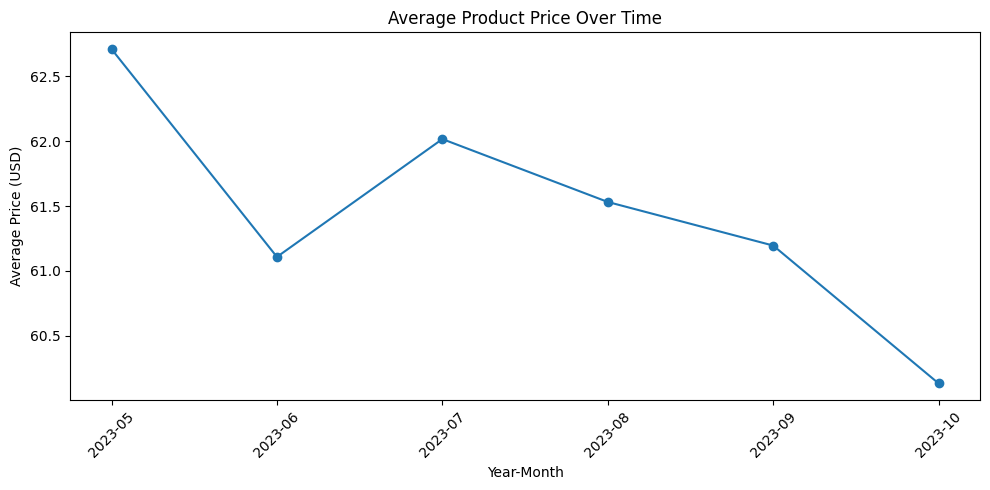

In [23]:
avg_price_month = (
    df.withColumn("year_month", F.date_format(F.col("stime_jst"), "yyyy-MM"))
      .groupBy("year_month")
      .agg(F.avg("price").alias("avg_price"))
      .orderBy("year_month")
)

price_month_df = avg_price_month.toPandas()

plt.figure(figsize=(10,5))
plt.plot(price_month_df["year_month"], price_month_df["avg_price"], marker="o")
plt.title("Average Product Price Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Category and Brand distributions

**Insights**
* The dataset exhibits a hierarchical category structure, where the number of unique categories increases substantially from C0 (17) to C1 (277) and C2 (2,713).
* Brand Name is the most diverse categorical feature, containing 18,405 unique values, indicating a marketplace with a large variety of manufacturers and sellers.

In [24]:
df.select(
    countDistinct("c0_name").alias("Unique C0 Categories"),
    countDistinct("c1_name").alias("Unique C1 Categories"),
    countDistinct("c2_name").alias("Unique C2 Categories"),
    countDistinct("brand_name").alias("Unique Brand Names")
).show()

[Stage 64:==========================================>              (9 + 3) / 12]

+--------------------+--------------------+--------------------+------------------+
|Unique C0 Categories|Unique C1 Categories|Unique C2 Categories|Unique Brand Names|
+--------------------+--------------------+--------------------+------------------+
|                  17|                 277|                2713|             18405|
+--------------------+--------------------+--------------------+------------------+



**Top 10 C0 Category Insights**
* The dataset exhibits a highly imbalanced category distribution, with the Women category dominating the marketplace.
* The large gap between the first and second categories indicates that fashion-related products represent a major portion of the available listings.
* Categories such as Home, Electronics, and Beauty maintain moderate representation, suggesting a diverse marketplace beyond fashion.
* Lower-frequency categories, including Books and Other, contribute a relatively small share of the overall inventory.

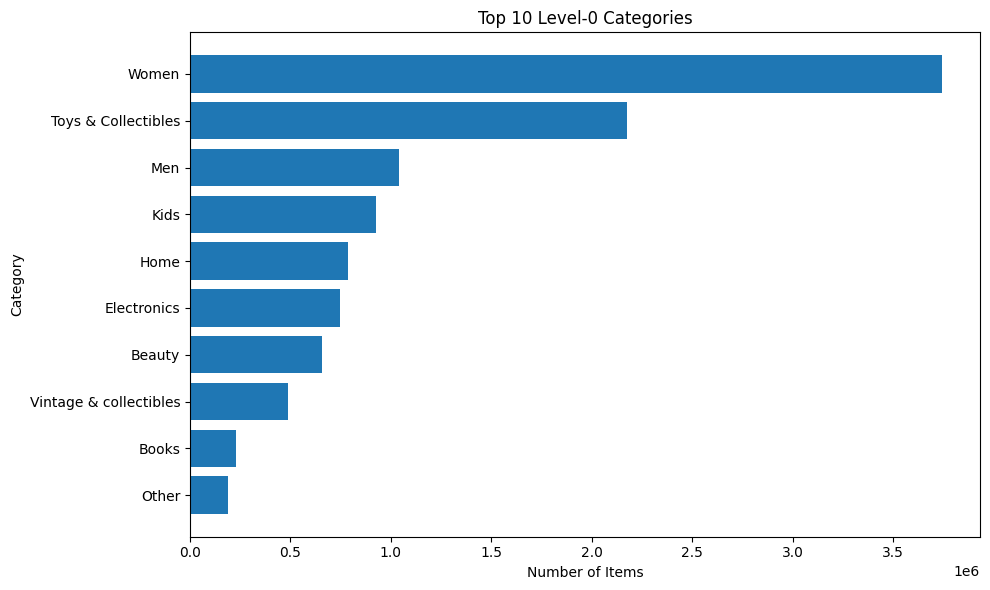

In [25]:
top_c0 = (
    df.groupBy("c0_name")
      .count()
      .orderBy(F.desc("count"))
      .limit(10)
)

top_c0_df = top_c0.toPandas()

plt.figure(figsize=(10, 6))
plt.barh(top_c0_df["c0_name"], top_c0_df["count"])
plt.gca().invert_yaxis() 
plt.title("Top 10 Level-0 Categories")
plt.xlabel("Number of Items")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

**Top 10 C1 Category Insights**
* The most frequently listed Level-1 categories are concentrated in fashion products (Shoes, Women's Handbags, Athletic Apparel, Tops & Blouses) and collectibles (Collectibles & Hobbies, Action Figures & Accessories).
* Shoes clearly dominates the Level-1 categories, indicating particularly high marketplace activity within the footwear segment.

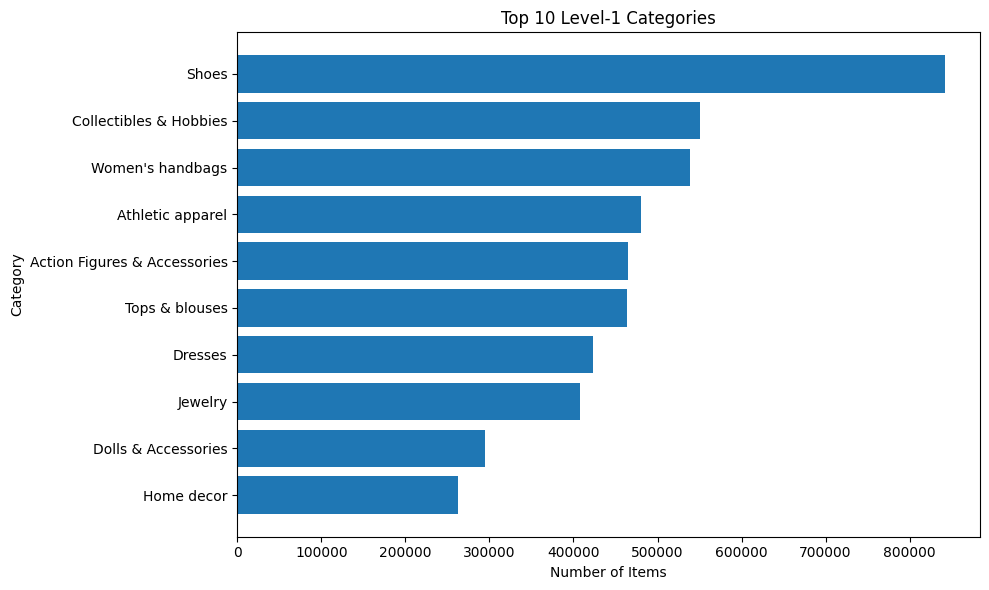

In [26]:
top_c1 = (
    df.groupBy("c1_name")
      .count()
      .orderBy(F.desc("count"))
      .limit(10)
)

top_c1_df = top_c1.toPandas()

plt.figure(figsize=(10, 6))
plt.barh(top_c1_df["c1_name"], top_c1_df["count"])
plt.gca().invert_yaxis() 
plt.title("Top 10 Level-1 Categories")
plt.xlabel("Number of Items")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

**Top 10 C2 Category Insights**
* The most frequently listed Level-2 categories are concentrated in fashion, toys, and children's products, suggesting these are the marketplace's primary product segments.
* The large "Other" category may indicate a considerable number of products with generic, miscellaneous, or incomplete classifications

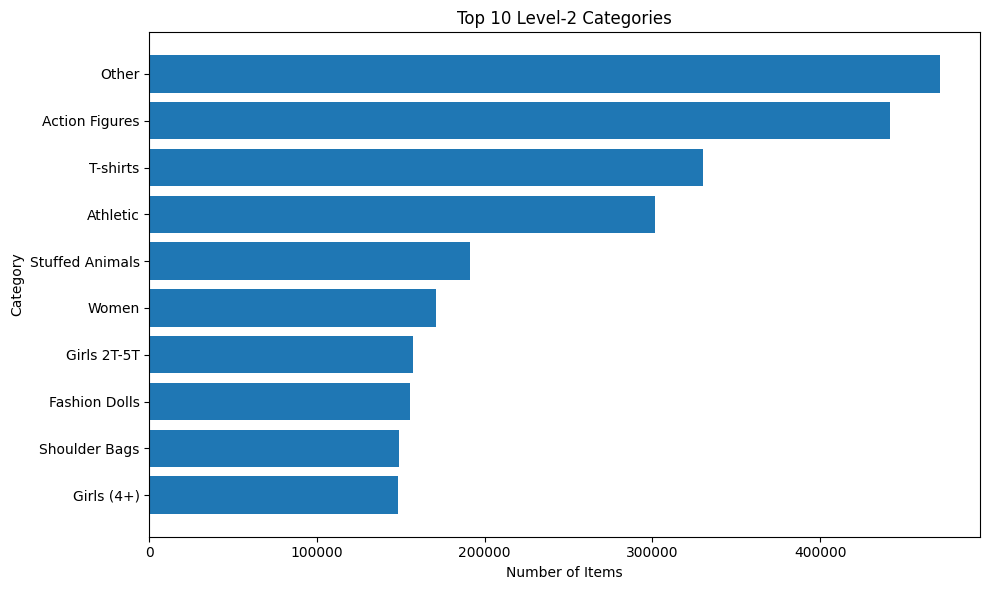

In [27]:
top_c2 = (
    df.groupBy("c2_name")
      .count()
      .orderBy(F.desc("count"))
      .limit(10)
)

top_c2_df = top_c2.toPandas()

plt.figure(figsize=(10, 6))
plt.barh(top_c2_df["c2_name"], top_c2_df["count"])
plt.gca().invert_yaxis() 
plt.title("Top 10 Level-2 Categories")
plt.xlabel("Number of Items")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

**Hierarchy Insights**
* The marketplace is dominated by a few major product segments, particularly toys, collectibles, fashion apparel, handbags, and fragrances.
* Action Figures alone account for more than 438,000 listings, significantly exceeding all other category combinations and demonstrating exceptionally high marketplace activity.
* The repeated appearance of Toys & Collectibles and Women's fashion indicates that these categories are the primary drivers of inventory volume.
* Fashion-related products appear across both Men and Women categories, suggesting apparel and accessories constitute a substantial portion of the marketplace.

In [28]:
top_category_combinations = (
    df.groupBy("c0_name", "c1_name", "c2_name")
      .count()
      .orderBy(F.desc("count"))
)

top_category_combinations.show(10, truncate=False)

[Stage 79:======================================>                  (8 + 4) / 12]

+-------------------+----------------------------+---------------+------+
|c0_name            |c1_name                     |c2_name        |count |
+-------------------+----------------------------+---------------+------+
|Toys & Collectibles|Action Figures & Accessories|Action Figures |438909|
|Toys & Collectibles|Stuffed Animals & Plush     |Stuffed Animals|191471|
|Men                |Shoes                       |Athletic       |189155|
|Men                |Tops                        |T-shirts       |177320|
|Beauty             |Fragrance                   |Women          |169515|
|Toys & Collectibles|Dolls & Accessories         |Fashion Dolls  |155656|
|Women              |Tops & blouses              |T-shirts       |152624|
|Women              |Women's handbags            |Shoulder Bags  |149025|
|Toys & Collectibles|Trading Cards               |Single Cards   |139934|
|Women              |Women's handbags            |Crossbody Bags |139093|
+-------------------+-----------------

**Top 10 brand Insights**
* Most of the items listed don't have any brand listed
* Nike is the most popular identifiable brand, reflecting its strong presence in the apparel and footwear market.
* Entertainment and collectible brands such as Disney, Funko, Nintendo, Pokémon, and BTS appear among the top brands, highlighting the importance of licensed merchandise and collectibles within the marketplace.
* Fashion-related brands, including Nike, lululemon athletica, and Coach, also have a significant presence, consistent with the earlier findings that fashion products dominate the dataset.

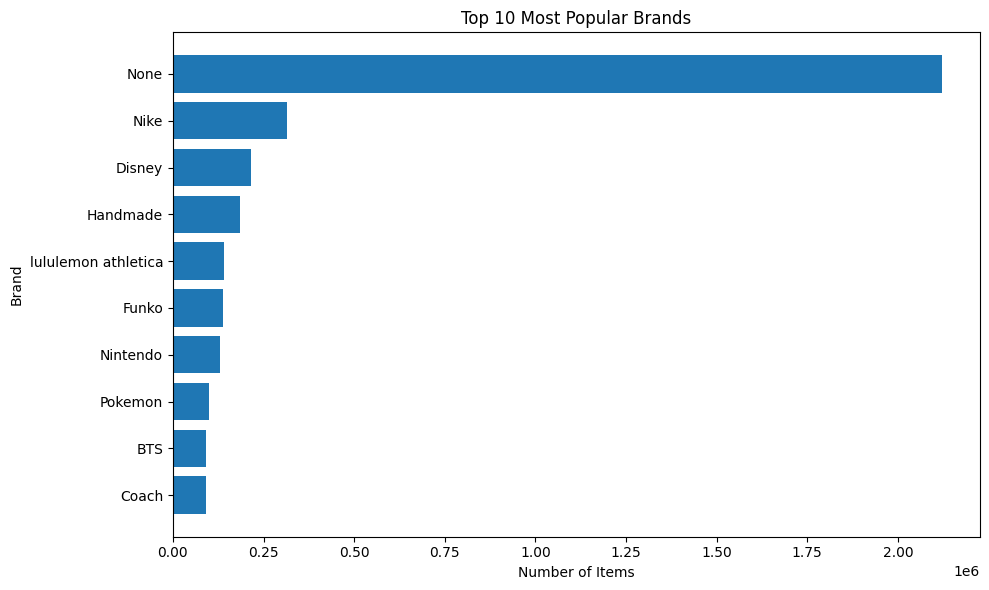

In [29]:
top_brands = (
    df.groupBy("brand_name")
      .count()
      .orderBy(F.desc("count"))
      .limit(10)
)

top_brands_df = top_brands.toPandas()

plt.figure(figsize=(10,6))
plt.barh(top_brands_df["brand_name"], top_brands_df["count"])
plt.title("Top 10 Most Popular Brands")
plt.xlabel("Number of Items")
plt.ylabel("Brand")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [30]:
total_products = df.count()

brand_percentage = (
    df.groupBy("brand_name")
      .agg(count("*").alias("product_count"))
      .withColumn(
          "percentage",
          round((col("product_count") / total_products) * 100, 2)
      )
      .orderBy(desc("product_count"))
)

brand_percentage.show(10, truncate=False)

[Stage 88:==========================================>              (9 + 3) / 12]

+-------------------+-------------+----------+
|brand_name         |product_count|percentage|
+-------------------+-------------+----------+
|None               |2120636      |18.55     |
|Nike               |315580       |2.76      |
|Disney             |214425       |1.88      |
|Handmade           |186020       |1.63      |
|lululemon athletica|141833       |1.24      |
|Funko              |138388       |1.21      |
|Nintendo           |131112       |1.15      |
|Pokemon            |98867        |0.86      |
|BTS                |92593        |0.81      |
|Coach              |91917        |0.8       |
+-------------------+-------------+----------+
only showing top 10 rows



## Item Condition

* The distribution is highly concentrated in the top three condition categories (Good, New, and Like New), which together account for the vast majority of product listings.
* The high proportion of products in Good and New condition suggests that sellers predominantly list products that are either unused or well maintained.
* Products in Fair and Poor condition constitute only a small percentage of the marketplace, indicating limited availability or lower consumer demand for heavily used items.

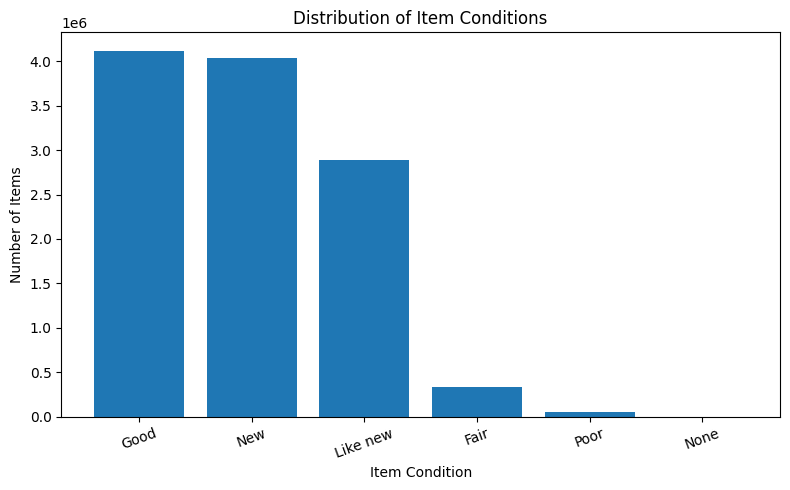

In [31]:
condition_dist = (
    df.groupBy("item_condition_name")
      .count()
      .orderBy(F.desc("count"))
)

item_condition_df = condition_dist.toPandas()

plt.figure(figsize=(8,5))
plt.bar(item_condition_df["item_condition_name"], item_condition_df["count"])
plt.title("Distribution of Item Conditions")
plt.xlabel("Item Condition")
plt.ylabel("Number of Items")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## User & Session Analysis

* The large number of unique users indicates a broad customer base
* The substantially higher number of sessions compared to users demonstrates that many users revisited the platform multiple times, indicating consistent user engagement
* The average of 3.7 sessions per user suggests recurring browsing or purchasing behavior

In [32]:
unique_users = df.select("user_id").distinct().count()
unique_sessions = df.select("session_id").distinct().count()

print('Number of Unique Users:', unique_users)
print('Number of Unique Sessions:', unique_sessions)

[Stage 107:============================================>           (8 + 2) / 10]

Number of Unique Users: 1990147
Number of Unique Sessions: 7358935


**Top 10 Users and their number of events Analysis**
* The most active user (User ID: 50727525) generated 1,375 events, making them the highest contributor to user interactions in the dataset.
* The remaining top users recorded between 920 and 1,240 events, indicating consistently high levels of engagement.
* The relatively small difference between the top-ranked users suggests that multiple users exhibit similarly intensive activity rather than a single user dominating the platform.

In [33]:
user_activity = (
    df.groupBy("user_id")
      .agg(count("*").alias("event_count"))
      .orderBy("event_count", ascending=False)
)

user_activity.show(10)

[Stage 113:>                                                        (0 + 4) / 4]

+--------+-----------+
| user_id|event_count|
+--------+-----------+
|50727525|       1375|
| 8300879|       1240|
|32736302|       1151|
|18148080|       1129|
|53991826|       1107|
|27303979|       1082|
|50009461|        965|
|13649653|        962|
|16891288|        947|
|26243510|        920|
+--------+-----------+
only showing top 10 rows



* The average of 5.74 events per user indicates moderate overall engagement across the platform.
* The contrast between the average user (5.74 events) and the most active users (over 1,000 events) suggests that the distribution of user activity is strongly right-skewed (long-tailed).

In [34]:
user_activity.select(avg("event_count").alias("Average Event Count")).show()

[Stage 116:>                                                        (0 + 4) / 4]

+-------------------+
|Average Event Count|
+-------------------+
|  5.743542059958385|
+-------------------+



**Top 10 Sessions and their number of events**
* Even the most active sessions contain fewer than 30 events, suggesting that individual browsing sessions are generally short and focused.
* The relatively narrow range of 21–29 events among the top sessions indicates that extremely long sessions are uncommon.

In [35]:
session_activity = (
    df.groupBy("session_id")
      .agg(count("*").alias("event_count"))
      .orderBy("event_count", ascending=False)
)

session_activity.show(10)

[Stage 122:============================================>           (8 + 2) / 10]

+--------------------+-----------+
|          session_id|event_count|
+--------------------+-----------+
|f8d772bebc5329728...|         29|
|885bbc5bd9d77eba9...|         25|
|65218d7bfda28aadd...|         24|
|1dd261549e944ccd6...|         23|
|18adfba35eea05da6...|         22|
|b80775716587e6a76...|         21|
|d1eef3c7f1e3b6ff6...|         21|
|12bcf886ea2f0f135...|         21|
|f14f82995f9ba789a...|         21|
|48a6734b65a60de36...|         21|
+--------------------+-----------+
only showing top 10 rows



* The low average of 1.55 events per session suggests that user interactions are generally short and focused.
* Compared with the average of 5.74 events per user, users interact with the platform across multiple sessions rather than completing all activities in a single visit.

In [36]:
session_activity.select(avg("event_count").alias("Average Event Count")).show()

[Stage 125:============================================>           (8 + 2) / 10]

+-------------------+
|Average Event Count|
+-------------------+
| 1.5532808755614773|
+-------------------+



**User and their number of Sessions Analysis**
* User engagement varies considerably across the platform, with a small group of users returning hundreds of times.
* Comparing this analysis with the earlier findings:
    * Average sessions per user: 3.70
    * Top users: 560–756 sessions
* This large difference indicates a highly right-skewed (long-tail) distribution of user activity, where a small proportion of users accounts for a disproportionately large number of visits.
* The consistency between high session counts and high event counts suggests that these users are highly loyal or highly engaged, repeatedly returning to interact with the platform.

In [37]:
sessions_per_user = (
    df.groupBy("user_id")
      .agg(countDistinct("session_id").alias("session_count"))
      .orderBy(desc("session_count"))
)

sessions_per_user.show(10)

[Stage 134:>                                                        (0 + 4) / 4]

+--------+-------------+
| user_id|session_count|
+--------+-------------+
| 8300879|          756|
| 6937872|          712|
|50727525|          686|
|27303979|          677|
| 9497805|          619|
|18148080|          616|
|13383611|          606|
|32736302|          581|
|53991826|          562|
|15114184|          560|
+--------+-------------+
only showing top 10 rows



## Temporal Analysis

* The event distribution follows a typical e-commerce conversion funnel, where the number of users decreases at each successive stage of the purchasing journey:
    * Product View → Like → Add to Cart → Offer → Purchase Initiation → Purchase Completion
* Browsing behavior dominates the dataset, with item_view accounting for the vast majority of interactions.
* There is a substantial drop between item_like and item_add_to_cart_tap, indicating that many users show interest in products but do not proceed to purchase intent.
* The relatively low number of buy_comp events compared with item_view suggests that only a small fraction of browsing sessions ultimately result in completed purchases.

In [38]:
event_distribution = (
    df.groupBy("event_id")
      .count()
      .orderBy(desc("count"))
)

event_distribution.show()

[Stage 135:=====================================>                  (8 + 4) / 12]

+--------------------+-------+
|            event_id|  count|
+--------------------+-------+
|           item_view|9513720|
|           item_like|1638210|
|item_add_to_cart_tap| 176941|
|          offer_make|  66888|
|           buy_start|  24516|
|            buy_comp|  10218|
+--------------------+-------+



**Events per Month Analysis**
* User activity exhibited a steady upward trend from May through August, suggesting increasing engagement over this period.
* August was the most active month, recording the highest volume of user interactions.
* The slight decline observed in September may indicate seasonal variation or normal fluctuations in marketplace activity.

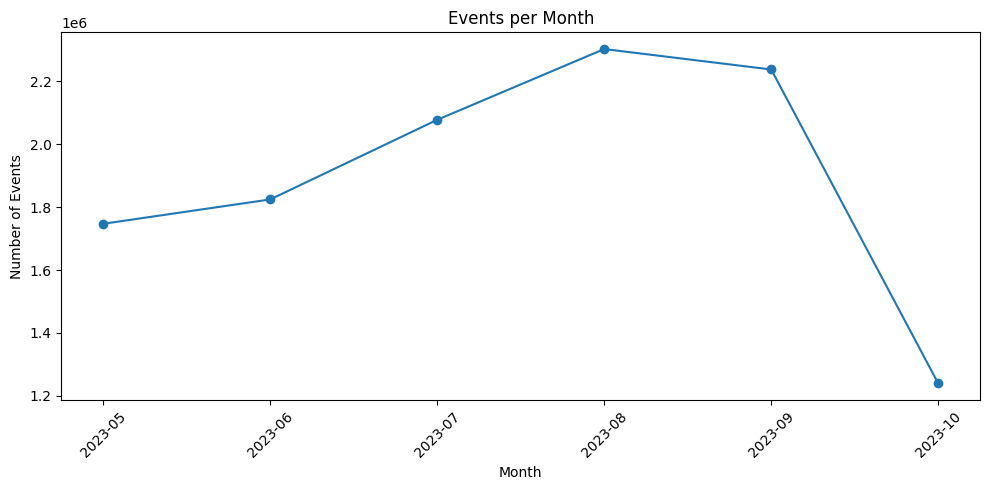

In [39]:
events_month = (
    df.withColumn("year_month", F.date_format(F.col("stime"), "yyyy-MM"))
      .groupBy("year_month")
      .count()
      .orderBy("year_month")
)

events_month_df = events_month.toPandas()

plt.figure(figsize=(10, 5))
plt.plot(events_month_df["year_month"], events_month_df["count"], marker="o")

plt.title("Events per Month")
plt.xlabel("Month")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Events by Day of the Week Analysis**
* User activity is well distributed across all days of the week, indicating consistent marketplace engagement.
* Sunday stands out as the most active day, suggesting that users are more likely to browse and interact with products during the weekend.
* The difference between the busiest day (Monday) and the least active days (Wednesday–Friday) is relatively small, indicating stable user engagement rather than strong weekly seasonality.

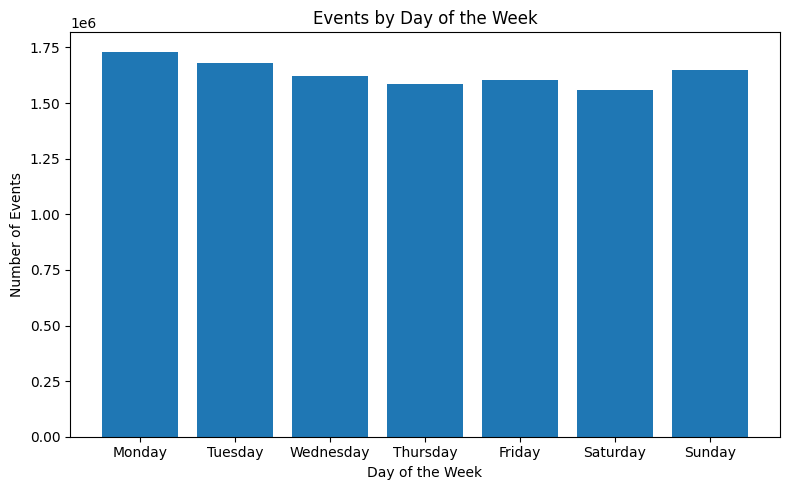

In [62]:
events_weekday = (
    df.withColumn("day_of_week", F.date_format("stime_jst", "EEEE"))
      .groupBy("day_of_week")
      .count()
)

weekday_order = ["Monday", "Tuesday", "Wednesday",
                 "Thursday", "Friday", "Saturday", "Sunday"]

events_weekday_df = events_weekday.toPandas()
events_weekday_df["day_of_week"] = pd.Categorical(
    events_weekday_df["day_of_week"],
    categories=weekday_order,
    ordered=True
)
events_weekday_df = events_weekday_df.sort_values("day_of_week")


plt.figure(figsize=(8,5))
plt.bar(events_weekday_df["day_of_week"], events_weekday_df["count"])
plt.title("Events by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.show()

**Events by Hour of Day Analysis**
* Update this ONE

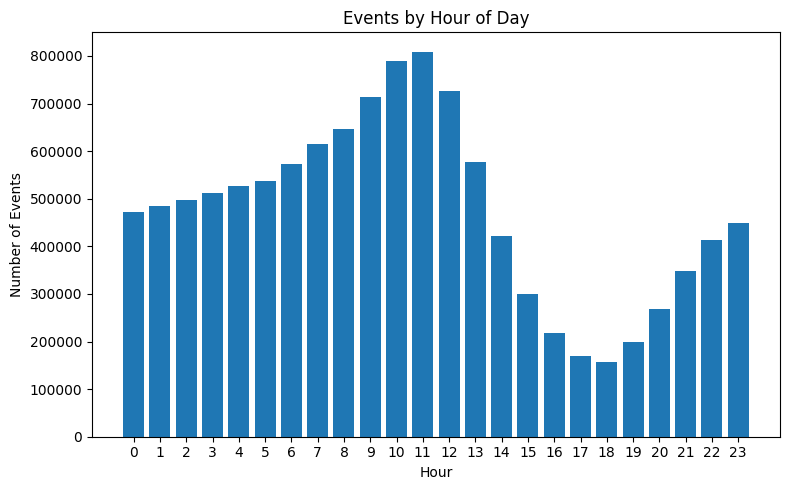

In [41]:
events_hour = (
    df.groupBy(F.hour("stime_jst").alias("hour"))
      .count()
      .orderBy("hour")
)

events_hour_df = events_hour.toPandas()

plt.figure(figsize=(8,5))
plt.bar(events_hour_df["hour"], events_hour_df["count"], width=0.8)
plt.title("Events by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

## Product Analysis

* The exceptionally high number of unique product names indicates low repetition across listings, which is characteristic of large online marketplaces.

In [42]:
df.select(
    countDistinct("name").alias("unique_product_names")
).show()

[Stage 159:========================================>                (5 + 2) / 7]

+--------------------+
|unique_product_names|
+--------------------+
|             7400850|
+--------------------+



* The most frequent product names are largely fashion and apparel items, reinforcing earlier findings that clothing and accessories are among the marketplace's dominant product categories.

In [43]:
top_products = (
    df.groupBy("name")
      .count()
      .orderBy(desc("count"))
)

top_products.show(10, truncate=False)

[Stage 165:========================================>                (5 + 2) / 7]

+-------+-----+
|name   |count|
+-------+-----+
|Dress  |19149|
|Nike   |7414 |
|Jeans  |5048 |
|Sandals|4610 |
|Jacket |4516 |
|Boots  |4438 |
|Heels  |4226 |
|Shorts |3691 |
|Shirt  |3586 |
|Hoodie |3349 |
+-------+-----+
only showing top 10 rows



* The highest-priced listings are concentrated in the luxury goods segment, particularly designer handbags and watches.
* Luxury brands consistently occupy the upper end of the marketplace's price distribution, reinforcing the earlier finding that brands such as Rolex, Chanel, and Louis Vuitton command significantly higher average prices.
* The repeated occurrence of identical product names indicates that the marketplace allows multiple listings for the same product model, likely from different sellers.

In [44]:
df.select("name", "brand_name", "price") \
  .orderBy(desc("price")) \
  .show(10, truncate=False)

[Stage 166:==================================================>    (11 + 1) / 12]

+--------------------------------------------------------------------------------+-------------+------+
|name                                                                            |brand_name   |price |
+--------------------------------------------------------------------------------+-------------+------+
|CHANEL ULTRA RARE Multicolor Resin CC Candy Supermarket Sweetie Triple Strand Ne|Chanel       |5000.0|
|Chanel wild stitch tote                                                         |Chanel       |5000.0|
|Cartier santos 100xl                                                            |Cartier      |5000.0|
|Vintage Chanel Dubai Messenger Shoulder Bag                                     |Chanel       |5000.0|
|Louis Vuitton Master collection Fragonard neverfull                             |Louis Vuitton|5000.0|
|Gucci x Balenciaga The Hacker Project leather hourglass bag                     |Gucci        |5000.0|
|Louis Vuitton Master collection Fragonard neverfull            

* Chanel is the most prominent luxury brand among the highest-priced products, occupying the majority of the top positions.
* The concentration of luxury handbags among the highest-priced items demonstrates the strong relationship between brand prestige and product value.

In [45]:
product_price = (
    df.groupBy("name")
      .agg(avg("price").alias("avg_price"))
      .orderBy(desc("avg_price"))
)

product_price.show(10, truncate=False)

[Stage 169:==========================================>              (6 + 2) / 8]

+-----------------------------------------------------------------------+---------+
|name                                                                   |avg_price|
+-----------------------------------------------------------------------+---------+
|GENUINE  Chanel Quilted Caviar                                         |5000.0   |
|Louis vuitton bum bag                                                  |5000.0   |
|Chanel pearl collar necklace                                           |5000.0   |
|Vintage Ladies Rolex Watch                                             |5000.0   |
|Chanel wild stitch tote                                                |5000.0   |
|***SOLD*****Chanel Classic Double Flap Quilted Caviar Jumbo            |5000.0   |
|Chanel Vintage Medium Double Flap Lambskin Quilted Bag Chain Black Gold|5000.0   |
|VINTAGE 1997 Louis Vuitton Sarah Wallet With Handbag                   |5000.0   |
|Chanel Mini Square flap bag in dark beige quilted lambskin             |500

* The marketplace includes 449,882 distinct products, reflecting a broad range of items across multiple categories and brands.
* Compared with the 11.43 million total records, each product appears multiple times in the dataset because products can generate several user interactions, such as views, likes, add-to-cart actions, offers, and purchases.

In [46]:
df.select(countDistinct("product_id").alias("Unique Products")).show()

[Stage 170:==================================================>    (11 + 1) / 12]

+---------------+
|Unique Products|
+---------------+
|         449882|
+---------------+



* Product 15987_1224 is the most viewed item in the dataset, receiving 64,092 views.
* The second most viewed product (7969_2428) accumulated 46,929 views, approximately 27% fewer than the top-ranked product.
* The remaining products each recorded between 30,000 and 43,000 views, indicating consistently high user interest.

In [47]:
df.filter(df.event_id == "item_view") \
  .groupBy("product_id") \
  .count() \
  .orderBy(desc("count")) \
  .show(10)

[Stage 176:=====================================>                  (8 + 4) / 12]

+----------+-----+
|product_id|count|
+----------+-----+
|15987_1224|64092|
| 7969_2428|46929|
|     0_561|43373|
|15928_1315|42931|
|     0_904|40745|
|  9814_561|34576|
|  436_1224|32731|
|  3838_585|31742|
| 8886_1176|31519|
|15987_1167|30331|
+----------+-----+
only showing top 10 rows



* Product 20165_645 recorded the highest number of completed purchases (127), making it the best-selling product in the dataset.
* Products 15928_1315 and 7969_2428 ranked second and third with 117 and 111 completed purchases, respectively.
* The remaining top-selling products recorded between 47 and 89 completed purchase

In [48]:
df.filter(df.event_id == "buy_comp") \
  .groupBy("product_id") \
  .count() \
  .orderBy(desc("count")) \
  .show(10)

[Stage 179:=====================================>                  (8 + 4) / 12]

+----------+-----+
|product_id|count|
+----------+-----+
| 20165_645|  127|
|15928_1315|  117|
| 7969_2428|  111|
|12864_2430|   89|
|  3838_585|   69|
|15987_1224|   64|
|17470_3525|   63|
|20652_1315|   62|
| 8886_1176|   49|
|     0_561|   47|
+----------+-----+
only showing top 10 rows



* Product 19587_1159 has the highest average price at 4800, making it the most expensive product on average in the dataset.
* The second and third highest-priced products have average prices of 3098.13 and 2769.00, respectively.
* Six of the top ten products share an average price of 2000, indicating a cluster of premium-priced items.

In [49]:
df.groupBy("product_id") \
  .agg(avg("price").alias("avg_price")) \
  .orderBy(desc("avg_price")) \
  .show(10)

[Stage 182:==========================================>             (9 + 3) / 12]

+----------+-----------------+
|product_id|        avg_price|
+----------+-----------------+
|19587_1159|           4800.0|
|  4769_459|         3098.125|
| 12906_765|           2769.0|
|18652_1154|2615.617435897436|
| 5246_2378|           2000.0|
|13368_3442|           2000.0|
|12906_1352|           2000.0|
|13241_2871|           2000.0|
|  3562_706|           2000.0|
|12621_1348|           2000.0|
+----------+-----------------+
only showing top 10 rows



* Most products exhibit price variability, with minimum and maximum prices differing substantially. This suggests that the same product may be listed at different prices by different sellers or at different points in time.
* Product 0_306 has the largest observed price range, varying from 1 to 1850, despite an average price of 61.13. Such a wide range may indicate premium variants, seller pricing strategies, or potential outliers.
* Product 4089_171 also shows considerable variation, with prices ranging from 1 to 650.
* In contrast, Product 15997_853 has identical minimum, maximum, and average prices (22.56), indicating that it was consistently listed at a single price throughout the dataset.

In [50]:
from pyspark.sql.functions import avg, min as spark_min, max as spark_max

df.groupBy("product_id").agg(
    avg("price").alias("avg_price"),
    spark_min("price").alias("min_price"),
    spark_max("price").alias("max_price")
).show(10)

[Stage 185:=============================================>         (10 + 2) / 12]

+----------+------------------+---------+---------+
|product_id|         avg_price|min_price|max_price|
+----------+------------------+---------+---------+
|  6146_349| 28.65515497553018|      2.0|    230.0|
|  7810_717|20.876605463502013|      2.0|    190.0|
|   436_192| 42.30137417218543|      4.0|    266.0|
|25659_1176| 18.05310810810811|      3.0|     75.0|
|  4089_171| 25.35001914791766|      1.0|    650.0|
| 15997_853|             22.56|    22.56|    22.56|
|  179_1159| 21.08291437549097|      1.0|    213.0|
| 24711_735|20.292250000000003|      2.0|     99.0|
|     0_306| 61.12891352549889|      1.0|   1850.0|
| 5685_2244|         28.749375|     13.0|     68.0|
+----------+------------------+---------+---------+
only showing top 10 rows



* Product 7969_2428 received the highest number of likes (21,778), making it the most liked product in the dataset.
* Products 20165_645 and 15928_1315 ranked second and third with 14,978 and 14,060 likes, respectively.
* The remaining products received between 7,282 and 13,058 likes, indicating consistently high levels of user interest.

In [51]:
df.filter(df.event_id == "item_like") \
  .groupBy("product_id") \
  .count() \
  .orderBy(desc("count")) \
  .show(10)

[Stage 188:=====================================>                  (8 + 4) / 12]

+----------+-----+
|product_id|count|
+----------+-----+
| 7969_2428|21778|
| 20165_645|14978|
|15928_1315|14060|
|  3838_585|13058|
|15987_1224|11593|
|17470_3525|11114|
|12864_2430|10655|
|  9814_561| 7901|
|     0_904| 7818|
| 13797_568| 7282|
+----------+-----+
only showing top 10 rows



* Product 7969_2428 recorded the highest number of add-to-cart events (2,655), indicating the strongest purchase intent among all products.
* Products 15928_1315 and 20165_645 ranked second and third with 2,058 and 1,999 cart additions, respectively.
* The remaining products accumulated between 742 and 1,908 add-to-cart events, demonstrating substantial customer interest.

In [52]:
df.filter(df.event_id == "item_add_to_cart_tap") \
  .groupBy("product_id") \
  .count() \
  .orderBy(desc("count")) \
  .show(10)

[Stage 191:=====================================>                  (8 + 4) / 12]

+----------+-----+
|product_id|count|
+----------+-----+
| 7969_2428| 2655|
|15928_1315| 2058|
| 20165_645| 1999|
|17470_3525| 1908|
|  3838_585| 1812|
|12864_2430| 1305|
|15987_1224| 1164|
|20652_1315| 1026|
|  9814_561|  902|
| 2388_2178|  742|
+----------+-----+
only showing top 10 rows



* Each product has one recorded view and one completed purchase, resulting in a 100% conversion rate.
* While this appears impressive, it is based on only a single customer interaction for each product.

In [53]:
conversion = (
    df.groupBy("product_id")
      .agg(
          sum(when(df.event_id=="item_view",1).otherwise(0)).alias("views"),
          sum(when(df.event_id=="buy_comp",1).otherwise(0)).alias("purchases")
      )
)

conversion = conversion.withColumn(
    "conversion_rate",
    conversion.purchases / conversion.views
)

conversion.orderBy(desc("conversion_rate")).show(10)

[Stage 194:==================================================>    (11 + 1) / 12]

+----------+-----+---------+---------------+
|product_id|views|purchases|conversion_rate|
+----------+-----+---------+---------------+
| 13616_770|    1|        1|            1.0|
| 2854_1006|    1|        1|            1.0|
| 4513_1139|    1|        1|            1.0|
|16829_2481|    1|        1|            1.0|
|15852_1305|    1|        1|            1.0|
|11791_1319|    1|        1|            1.0|
| 6151_1168|    1|        1|            1.0|
| 17129_212|    1|        1|            1.0|
|  5683_756|    1|        1|            1.0|
|  477_1198|    1|        1|            1.0|
+----------+-----+---------+---------------+
only showing top 10 rows



* Products with a high number of unique users are likely to have broad visibility and widespread customer interest, rather than repeated interactions from a small group of users.
* Several products, including 15987_1224, 7969_2428, 0_561, and 15928_1315, also ranked among the most viewed products. This indicates that their popularity is driven by engagement from many different users rather than repeated views by the same individuals.

In [54]:
df.groupBy("product_id") \
  .agg(countDistinct("user_id").alias("unique_users")) \
  .orderBy(desc("unique_users")) \
  .show(10)

[Stage 199:>                                                        (0 + 4) / 4]

+----------+------------+
|product_id|unique_users|
+----------+------------+
|15987_1224|       50755|
| 7969_2428|       39589|
|     0_561|       38393|
|15928_1315|       36609|
|     0_904|       35174|
| 8886_1176|       31524|
|15987_1167|       28953|
|    0_1176|       28872|
|  436_1224|       24794|
|     0_717|       23402|
+----------+------------+
only showing top 10 rows



* Products with a high number of sessions are frequently encountered across many shopping sessions, suggesting strong marketplace exposure and sustained customer interest.
* Several products, including 15987_1224, 7969_2428, 15928_1315, 0_561, and 0_904, consistently appear among the most viewed, most liked, most added-to-cart, most purchased, and highest unique user rankings. This demonstrates that these products maintain strong engagement throughout the customer journey.

In [55]:
df.groupBy("product_id") \
  .agg(countDistinct("session_id").alias("sessions")) \
  .orderBy(desc("sessions")) \
  .show(10)

[Stage 205:===================================================>   (14 + 1) / 15]

+----------+--------+
|product_id|sessions|
+----------+--------+
|15987_1224|   76326|
| 7969_2428|   71034|
|15928_1315|   59500|
|     0_561|   49973|
|     0_904|   48672|
|  3838_585|   45677|
|  9814_561|   42908|
|  436_1224|   39195|
|17470_3525|   39008|
|12864_2430|   37754|
+----------+--------+
only showing top 10 rows



* All of the top 20 product-event combinations correspond to item_view events, indicating that viewing products is by far the most common user activity.
* Product 15987_1224 received the highest number of views (64,092), making it the most frequently viewed product in the dataset.

In [56]:
df.groupBy("product_id", "event_id") \
  .count() \
  .orderBy(desc("count")) \
  .show(20, truncate=False)

+----------+---------+-----+
|product_id|event_id |count|
+----------+---------+-----+
|15987_1224|item_view|64092|
|7969_2428 |item_view|46929|
|0_561     |item_view|43373|
|15928_1315|item_view|42931|
|0_904     |item_view|40745|
|9814_561  |item_view|34576|
|436_1224  |item_view|32731|
|3838_585  |item_view|31742|
|8886_1176 |item_view|31519|
|15987_1167|item_view|30331|
|0_1176    |item_view|29884|
|15568_568 |item_view|27185|
|17470_3525|item_view|26126|
|12864_2430|item_view|25717|
|0_717     |item_view|25438|
|7969_561  |item_view|25070|
|2388_2178 |item_view|24910|
|2595_568  |item_view|24797|
|0_1160    |item_view|24209|
|15928_1314|item_view|23759|
+----------+---------+-----+
only showing top 20 rows



* Product 15987_1224 recorded the highest overall engagement with 77,722 user interactions, making it the most interacted-with product in the dataset.
* Product 7969_2428 ranked second with 72,702 interactions, followed by 15928_1315 with 60,500 interactions.
* All products in the top ten received more than 38,000 interactions, indicating consistently high levels of customer engagement.

In [57]:
df.groupBy("product_id") \
  .count() \
  .orderBy(desc("count")) \
  .show(10)

[Stage 212:=============================================>         (10 + 2) / 12]

+----------+-----+
|product_id|count|
+----------+-----+
|15987_1224|77722|
| 7969_2428|72702|
|15928_1315|60500|
|     0_561|50439|
|     0_904|49565|
|  3838_585|46944|
|  9814_561|43768|
|17470_3525|39910|
|  436_1224|39875|
|12864_2430|38499|
+----------+-----+
only showing top 10 rows



## Correlation Analysis

In [61]:
pdf = (
    df.select(
        "event_id",
        "c0_name",
        "c1_name",
        "c2_name",
        "brand_name",
        "item_condition_name",
        "price"
    )
    .sample(fraction=0.1, seed=42)
    .toPandas()
)

In [63]:
numeric_cols = [
    "price"
]

categorical_cols = [
    "c0_name",
    "c1_name",
    "c2_name",
    "brand_name",
    "item_condition_name",
    "event_id"
]

In [77]:
pdf.head()

,event_id,c0_name,c1_name,c2_name,brand_name,item_condition_name,price
0,item_like,Electronics,Video games & consoles,Games,Nintendo,New,47.0
1,item_view,Women,Women's handbags,Satchel,Coach,New,249.0
2,item_view,Electronics,Other,Other,None,New,15.0
3,item_like,Women,Women's handbags,Tote Bags,Coach,New,298.0
4,item_view,Kids,Boys tops & t-shirts,Boys (4+),abercrombie kids,Good,10.0


In [87]:
def cramers_v(pdf, col1, col2):

    data = pdf[[col1, col2]].dropna()

    confusion_matrix = pd.crosstab(data[col1], data[col2])

    # Need at least 2 categories in each variable
    if confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
        return np.nan

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.values.sum()

    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denom = min(kcorr - 1, rcorr - 1)

    if denom <= 0:
        return np.nan

    return np.sqrt(phi2corr / denom)

In [88]:
cramers_matrix = pd.DataFrame(
    index=categorical_cols,
    columns=categorical_cols,
    dtype=float
)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            cramers_matrix.loc[col1, col2] = 1.0
        else:
            cramers_matrix.loc[col1, col2] = cramers_v(pdf, col1, col2)

print(cramers_matrix)

                      c0_name   c1_name   c2_name  brand_name  \
c0_name              1.000000  0.952637  0.951924    0.558198   
c1_name              0.952637  1.000000  0.932307    0.364947   
c2_name              0.951924  0.932307  1.000000    0.227430   
brand_name           0.558198  0.364947  0.227430    1.000000   
item_condition_name  0.120174  0.164001  0.195893    0.198742   
event_id             0.035069  0.046992  0.056830    0.051761   

                     item_condition_name  event_id  
c0_name                         0.120174  0.035069  
c1_name                         0.164001  0.046992  
c2_name                         0.195893  0.056830  
brand_name                      0.198742  0.051761  
item_condition_name             1.000000  0.016732  
event_id                        0.016732  1.000000  


In [89]:
def correlation_ratio(pdf, cat_col, num_col):
    data = pdf[[cat_col, num_col]].dropna()

    categories = pd.Categorical(data[cat_col])
    measurements = data[num_col].values

    grand_mean = np.mean(measurements)

    numerator = 0
    denominator = np.sum((measurements - grand_mean) ** 2)

    for category in categories.categories:
        values = measurements[categories == category]

        if len(values) == 0:
            continue

        numerator += len(values) * (np.mean(values) - grand_mean) ** 2

    if denominator == 0:
        return np.nan

    return np.sqrt(numerator / denominator)

In [90]:
eta_matrix = pd.DataFrame(
    index=categorical_cols,
    columns=numeric_cols,
    dtype=float
)

for cat in categorical_cols:
    for num in numeric_cols:
        eta_matrix.loc[cat, num] = correlation_ratio(
            pdf,
            cat,
            num
        )

print(eta_matrix)

                        price
c0_name              0.117701
c1_name              0.253735
c2_name              0.320899
brand_name           0.453682
item_condition_name  0.019712
event_id             0.035541


## Combining all categories into one path

In [91]:
pdf["category_path"] = (
    pdf["c0_name"] + " > " +
    pdf["c1_name"] + " > " +
    pdf["c2_name"]
)

categorical_cols = [
    "category_path",
    "brand_name",
    "item_condition_name",
    "event_id"
]

numeric_cols = [
    "price"
]

In [92]:
cramers_matrix = pd.DataFrame(
    index=categorical_cols,
    columns=categorical_cols,
    dtype=float
)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            cramers_matrix.loc[col1, col2] = 1.0
        else:
            cramers_matrix.loc[col1, col2] = cramers_v(pdf, col1, col2)

print(cramers_matrix)

                     category_path  brand_name  item_condition_name  event_id
category_path             1.000000    0.212961             0.201410  0.056642
brand_name                0.212961    1.000000             0.198742  0.051761
item_condition_name       0.201410    0.198742             1.000000  0.016732
event_id                  0.056642    0.051761             0.016732  1.000000


In [93]:
eta_matrix = pd.DataFrame(
    index=categorical_cols,
    columns=numeric_cols,
    dtype=float
)

for cat in categorical_cols:
    for num in numeric_cols:
        eta_matrix.loc[cat, num] = correlation_ratio(
            pdf,
            cat,
            num
        )

print(eta_matrix)

                        price
category_path        0.328385
brand_name           0.453682
item_condition_name  0.019712
event_id             0.035541
